# EM Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.utils import shuffle

## Generate Data

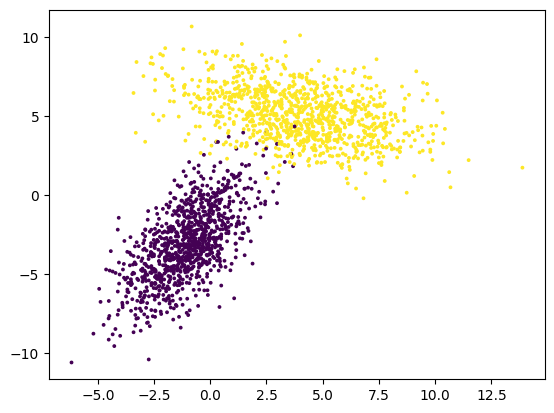

In [3]:
num_points = 1000

mean_1 = [-1, -3]
cov_1 = [[2, 2], [2, 5]]
x_1 = np.random.multivariate_normal(mean_1, cov_1, num_points)

mean_2 = [4, 5]
cov_2 = [[7, -2], [-2, 3]]
x_2 = np.random.multivariate_normal(mean_2, cov_2, num_points)

X = np.concatenate([x_1, x_2])
y = np.array([0] * num_points + [1] *  num_points) 
X, y = shuffle(X, y, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s = 3, c = y)

## Silhouette score

In [4]:
for i in range(2, 5):
    gmm = GaussianMixture(n_components=i, covariance_type='full')
    gmm_labels = gmm.fit_predict(X)
    silhouette_avg = silhouette_score(X, gmm_labels)
    print("For n_clusters =", i, " silhouette average:", silhouette_avg)

For n_clusters = 2  silhouette average: 0.6356745194942887
For n_clusters = 3  silhouette average: 0.4808353026383355
For n_clusters = 4  silhouette average: 0.41279401140537575


## Covariance type

In [5]:
GMM = GaussianMixture(n_components=2, covariance_type='full')
GMM.fit(X)
print('means ')
print(GMM.means_)
print('covariances ')
print(GMM.covariances_)

means 
[[-1.07732865 -3.11241253]
 [ 3.96432069  5.07770392]]
covariances 
[[[ 2.00240136  2.02717344]
  [ 2.02717344  5.21319601]]

 [[ 7.02831188 -1.76213855]
  [-1.76213855  2.85766779]]]


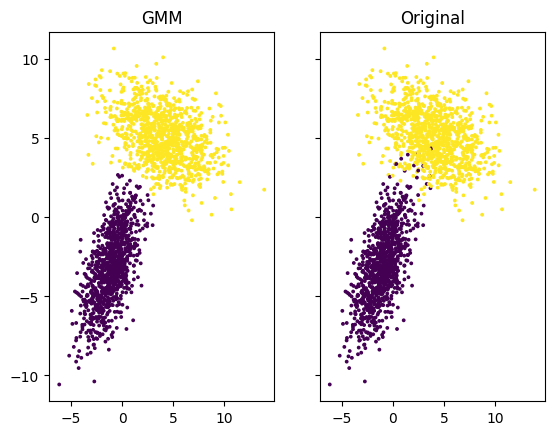

In [6]:
labels = GMM.predict(X)

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.set_title('GMM')
ax1.scatter(X[:,0], X[:,1], c=labels, s=3)
ax2.set_title("Original")
ax2.scatter(X[:,0], X[:,1], c=y, s=3)

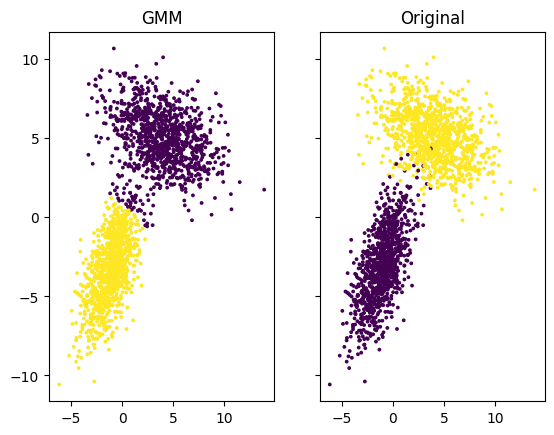

In [7]:
GMM = GaussianMixture(n_components=2, covariance_type='spherical')
GMM.fit(X)

labels = GMM.predict(X)

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.set_title('GMM')
ax1.scatter(X[:,0], X[:,1], c=labels, s=3)
ax2.set_title("Original")
ax2.scatter(X[:,0], X[:,1], c=y, s=3)

EM‑кластеризацію через GaussianMixture: тут відбувається дві анізотропні 2D‑гаусіани, порівнюється якість за середнім силуетом для різних n_components і візуально зіставляєш передбачені мітки з «оригінальними». Для даних з двома джерелами найкращим очікувано виходить k=2, причому covariance_type= full добре відновлює нахилені еліпси, а spherical нав’язує круглі ізовариаційні контури і гірше моделює анізотропію.

Спочатку генерація вибірок з середніми і повними ковариаціями зшиваються в X, y; shuffle перемішує порядок рядків. Після емулює два «подкласи» з різною дисперсією та кореляцією.​


Оцінка параметрів: EM повертає means_ і covariances_; у 'full' кожен компонент має власну повну матрицю, у 'spherical' — лише скалярну дисперсію на компонент, тому еліпси спрощуються до кіл.​